In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ranking = pd.read_csv('../data/processed/ranking_prioridad_clinica.csv')

sns.set_style("whitegrid")

print("="*70)
print("RANKING SUMMARY")
print("="*70)

print(f"Total patients: {len(ranking):,}")
print(f"Average Abnormal Probability: {ranking['prob_abnormal'].mean():.3f}")


RANKING SUMMARY
Total patients: 240
Average Abnormal Probability: 0.318


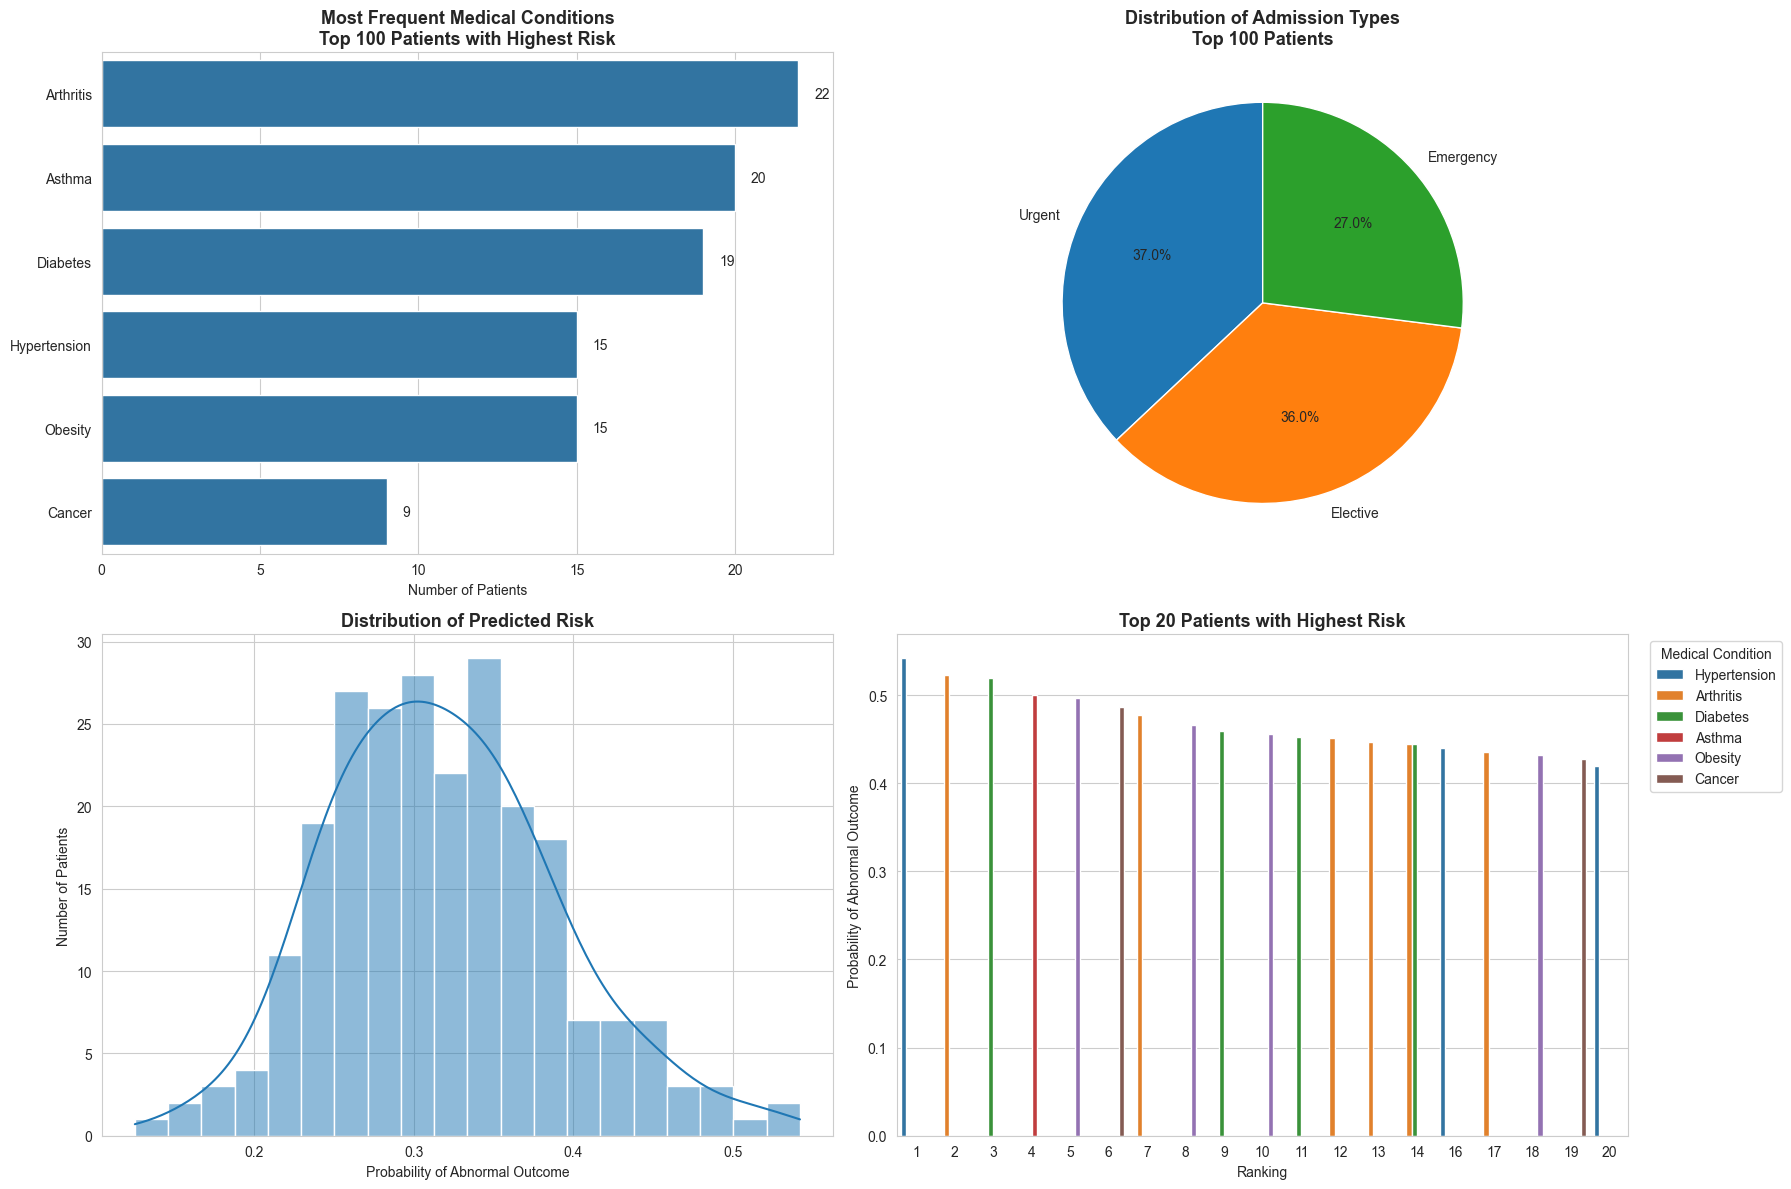

In [29]:

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

top100 = ranking.head(100)

condiciones = top100['Medical Condition_label'].value_counts()

sns.barplot(
    x=condiciones.values,
    y=condiciones.index,
    ax=axes[0,0]
)

axes[0,0].set_title(
    'Most Frequent Medical Conditions\nTop 100 Patients with Highest Risk',
    fontsize=13,
    fontweight='bold'
)

axes[0,0].set_xlabel('Number of Patients')
axes[0,0].set_ylabel('')

for i, v in enumerate(condiciones.values):
    axes[0,0].text(v + 0.5, i, str(v), va='center')


admision = top100['Admission Type_label'].value_counts()

axes[0,1].pie(
    admision.values,
    labels=admision.index,
    autopct='%1.1f%%',
    startangle=90
)

axes[0,1].set_title(
    'Distribution of Admission Types\nTop 100 Patients',
    fontsize=13,
    fontweight='bold'
)


sns.histplot(
    ranking['prob_abnormal'],
    bins=20,
    kde=True,
    ax=axes[1,0]
)

axes[1,0].set_title(
    'Distribution of Predicted Risk',
    fontsize=13,
    fontweight='bold'
)

axes[1,0].set_xlabel('Probability of Abnormal Outcome')
axes[1,0].set_ylabel('Number of Patients')


top20 = ranking.head(20)

sns.barplot(
    data=top20,
    x='priority_rank',
    y='prob_abnormal',
    hue='Medical Condition_label',
    ax=axes[1,1]
)

axes[1,1].set_title(
    'Top 20 Patients with Highest Risk',
    fontsize=13,
    fontweight='bold'
)

axes[1,1].set_xlabel('Ranking')
axes[1,1].set_ylabel('Probability of Abnormal Outcome')

axes[1,1].legend(
    title='Medical Condition',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


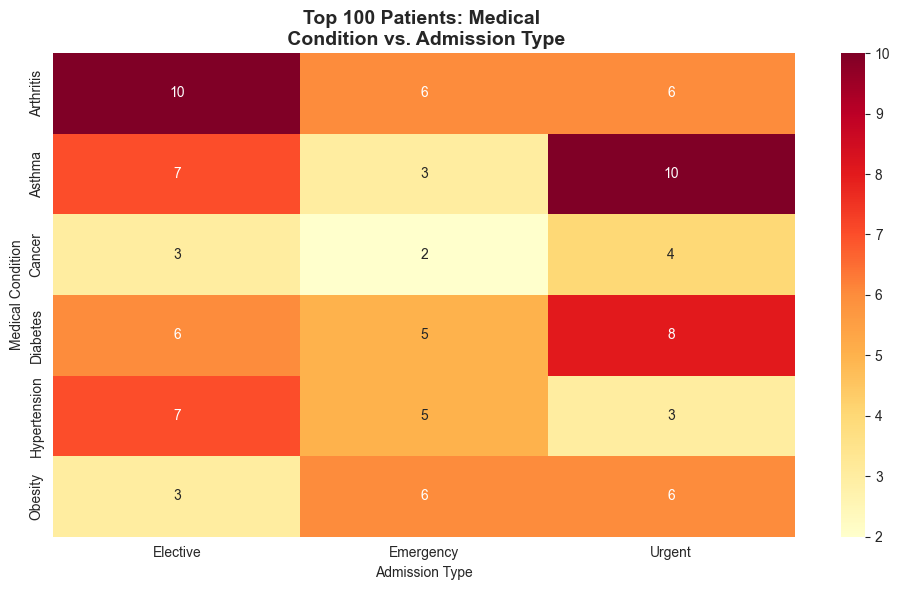

In [27]:

plt.figure(figsize=(10, 6))

tabla = pd.crosstab(
    top100['Medical Condition_label'],
    top100['Admission Type_label']
)

sns.heatmap(
    tabla,
    annot=True,
    fmt='d',
    cmap='YlOrRd'
)

plt.title(
    'Top 100 Patients: Medical \n Condition vs. Admission Type',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Admission Type')
plt.ylabel('Medical Condition')

plt.tight_layout()
plt.show()

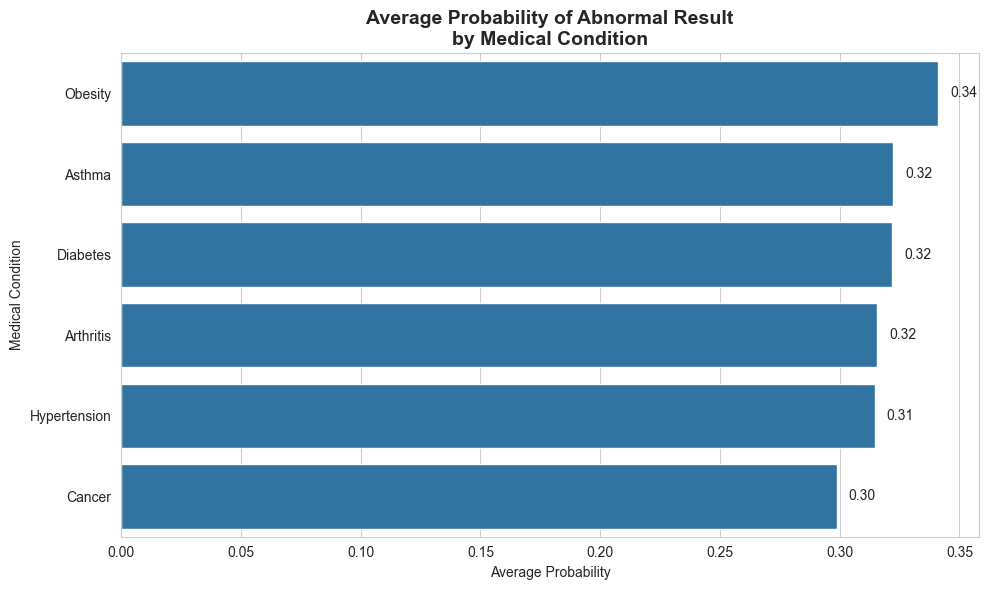

In [28]:

riesgo_condicion = (
    ranking.groupby('Medical Condition_label')['prob_abnormal']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=riesgo_condicion.values,
    y=riesgo_condicion.index
)

plt.title(
    'Average Probability of Abnormal Result\nby Medical Condition',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Average Probability')
plt.ylabel('Medical Condition')

for i, v in enumerate(riesgo_condicion.values):
    plt.text(v + 0.005, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

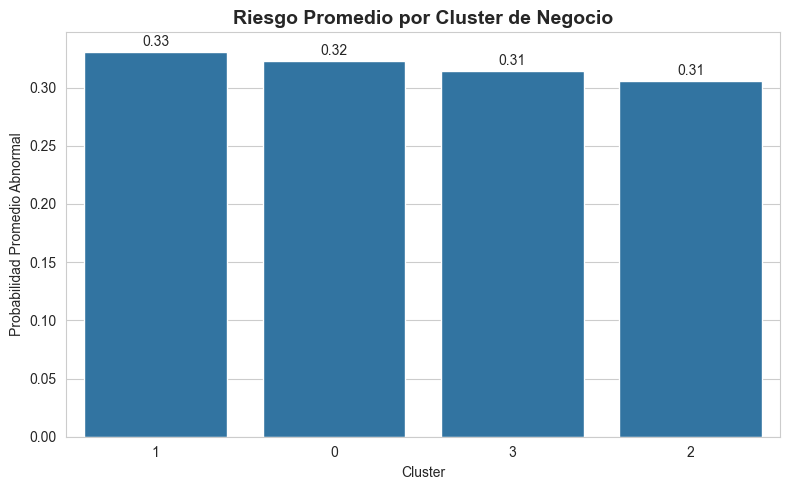

In [23]:
if 'Cluster_Biz' in ranking.columns:

    cluster_risk = (
        ranking.groupby('Cluster_Biz')['prob_abnormal']
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8,5))

    sns.barplot(
        x=cluster_risk.index.astype(str),
        y=cluster_risk.values
    )

    plt.title(
        'Riesgo Promedio por Cluster de Negocio',
        fontsize=14,
        fontweight='bold'
    )

    plt.xlabel('Cluster')
    plt.ylabel('Probabilidad Promedio Abnormal')

    for i, v in enumerate(cluster_risk.values):
        plt.text(i, v + 0.005, f'{v:.2f}', ha='center')

    plt.tight_layout()
    plt.show()

In [24]:

print("\n" + "="*70)
print("PRECISIÓN DEL RANKING")
print("="*70)

for n in [10, 20, 50, 100]:

    top_n = ranking.head(n)

    precision = (
        top_n['real_class']
        .eq('Abnormal')
        .mean()
    )

    print(
        f"Top-{n:<3} -> "
        f"{precision:.2%} "
        f"({int(precision*n)}/{n} realmente Abnormal)"
    )

print("\n" + "="*70)
print("RIESGO PROMEDIO POR CONDICIÓN MÉDICA")
print("="*70)

print(riesgo_condicion.round(3))


PRECISIÓN DEL RANKING
Top-10  -> 20.00% (2/10 realmente Abnormal)
Top-20  -> 40.00% (8/20 realmente Abnormal)
Top-50  -> 32.00% (16/50 realmente Abnormal)
Top-100 -> 31.00% (31/100 realmente Abnormal)

RIESGO PROMEDIO POR CONDICIÓN MÉDICA
Medical Condition_label
Obesity         0.341
Asthma          0.322
Diabetes        0.322
Arthritis       0.316
Hypertension    0.315
Cancer          0.299
Name: prob_abnormal, dtype: float64
